In [1]:
import os
import time
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, RepeatVector
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Create images directory
os.makedirs('images', exist_ok=True)

# Download and extract UCI HAR dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "UCI_HAR_Dataset.zip"
extract_path = "UCI_HAR_Dataset"

if not os.path.exists(extract_path):
    print("Downloading UCI HAR Dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("Download and extraction complete.")

Download and extraction complete.


/tmp/ipykernel_58/1439980256.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_58/1439980256.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_58/1439980256.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_58/1439980256.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_58/1439980256

Training shape: (2472, 128, 9)
Validation shape: (528, 128, 9)
Testing shape: (2947, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


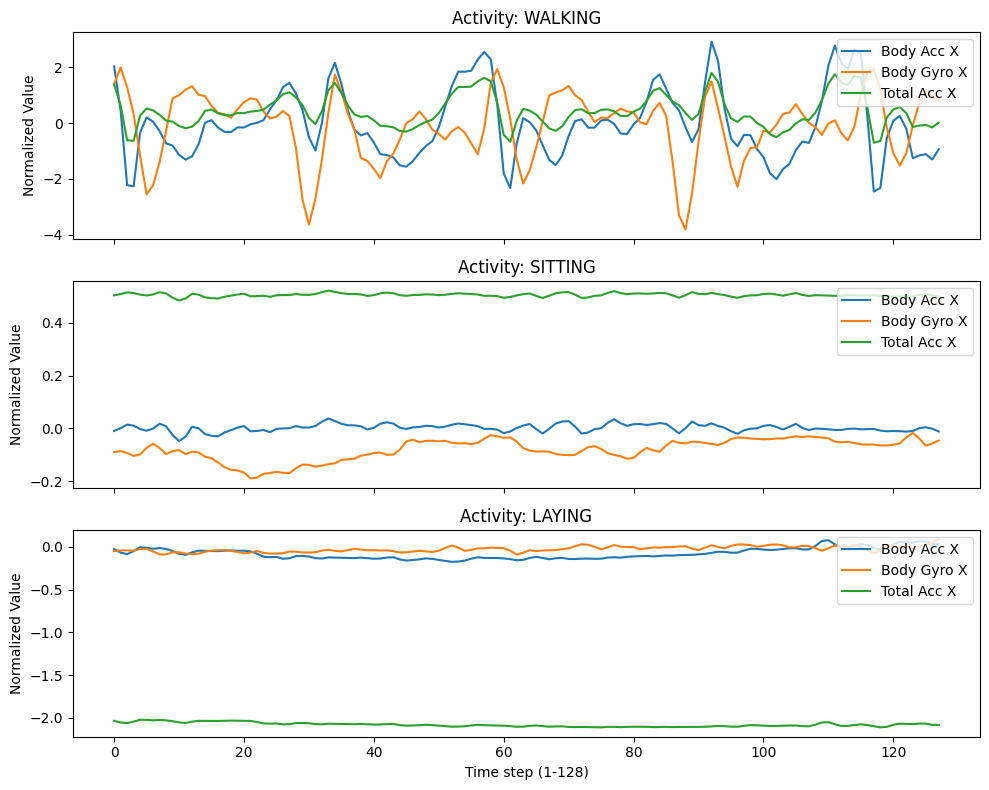

In [3]:
# UCI HAR Preprocessing and Visualization (Plot 1)
# This block loads the raw inertial signals, normalizes them, prints the expected shapes, and generates the temporal data visualization.

def load_signals(subset):
    signals_data = []
    base_path = f"UCI HAR Dataset/{subset}/Inertial Signals/"
    signals = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_"
    ]
    for signal in signals:
        filename = f"{base_path}{signal}{subset}.txt"
        df = pd.read_csv(filename, delim_whitespace=True, header=None)
        signals_data.append(df.values)
    return np.transpose(signals_data, (1, 2, 0))

def load_labels(subset):
    filename = f"UCI HAR Dataset/{subset}/y_{subset}.txt"
    df = pd.read_csv(filename, delim_whitespace=True, header=None)
    return df.values.flatten() - 1  # 0-indexed labels

# Load raw data
X_train_full = load_signals('train')
y_train_full = load_labels('train')
X_test = load_signals('test')
y_test = load_labels('test')

# Laboratory subset (using first 3000 to keep execution fast, as recommended)
X_subset, _, y_subset, _ = train_test_split(X_train_full, y_train_full, train_size=3000, stratify=y_train_full, random_state=42)

# Create Train/Val split (85/15 of the 70% subset train logic)
X_train, X_val, y_train, y_val = train_test_split(X_subset, y_subset, test_size=0.176, stratify=y_subset, random_state=42) # ~70/15/15 overall

# Normalization based on training data
mean = np.mean(X_train, axis=(0, 1))
std = np.std(X_train, axis=(0, 1))
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")

# Plot 1: Sensor signal versus time
activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
sample_indices = [np.where(y_train == i)[0][0] for i in [0, 3, 5]] # WALKING, SITTING, LAYING

for ax, idx, act_name in zip(axes, sample_indices, ['WALKING', 'SITTING', 'LAYING']):
    ax.plot(X_train[idx, :, 0], label='Body Acc X')
    ax.plot(X_train[idx, :, 3], label='Body Gyro X')
    ax.plot(X_train[idx, :, 6], label='Total Acc X')
    ax.set_title(f"Activity: {act_name}")
    ax.set_ylabel("Normalized Value")
    ax.legend(loc='upper right')

axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.savefig('images/1_sensor_signals.png')
plt.show()


Training RNN...


I0000 00:00:1789720322.592095      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789720322.595194      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1789720328.304521     162 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


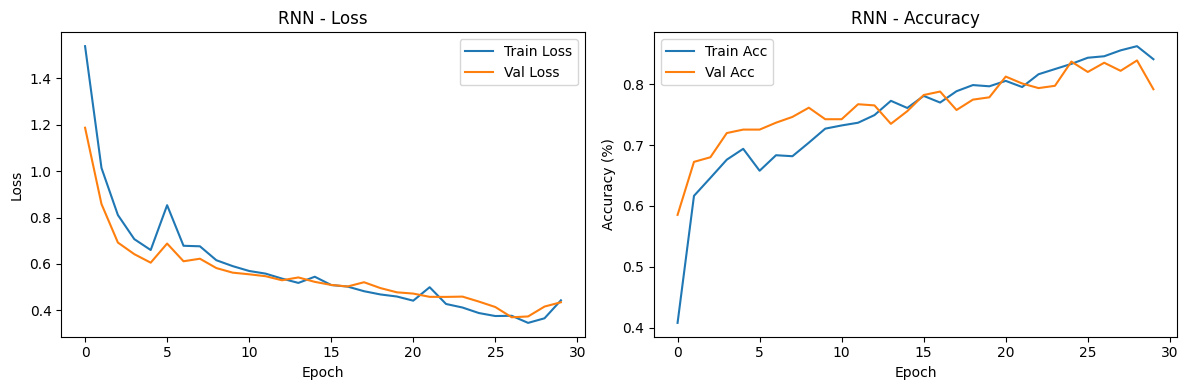


Training LSTM...


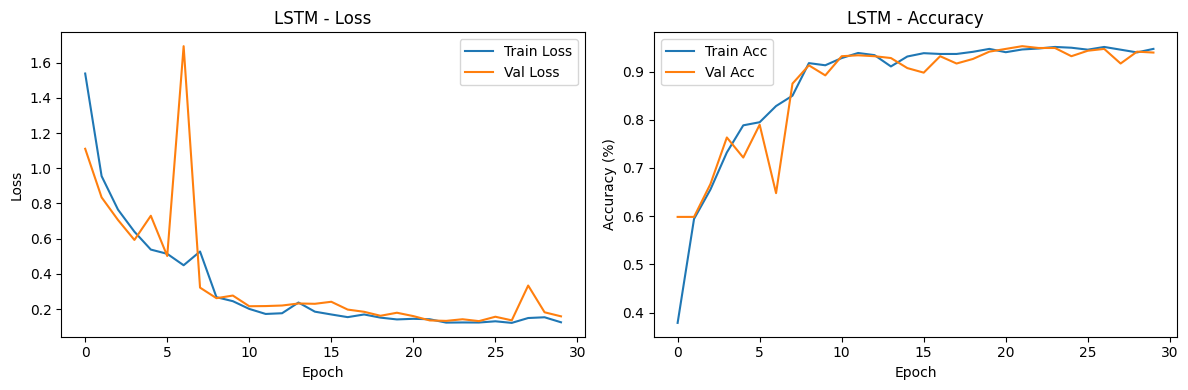


Training GRU...


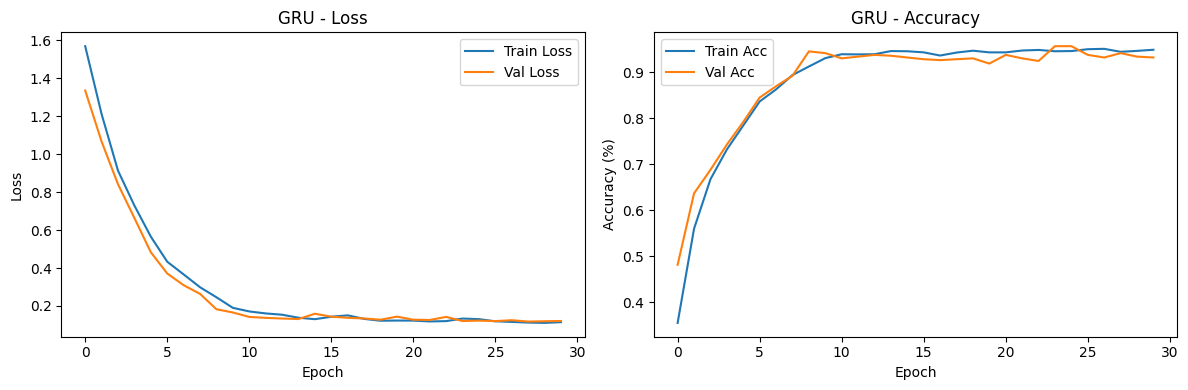

In [4]:
# Model Definitions, Training, and Convergence Plots (Plots 2 & 3)
# Trains the SimpleRNN, LSTM, and GRU models and visualizes the loss and accuracy.

def build_model(cell_type, units=32, input_shape=(128, 9), num_classes=6):
    model = Sequential()
    if cell_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=input_shape))
    elif cell_type == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape))
    elif cell_type == 'GRU':
        model.add(GRU(units, input_shape=input_shape))
        
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=1e-3), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

models = ['RNN', 'LSTM', 'GRU']
histories = {}
trained_models = {}
train_times = {}
params_count = {}

for m in models:
    print(f"\nTraining {m}...")
    model = build_model(m)
    params_count[m] = model.count_params()
    
    start_time = time.time()
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, 
                        validation_data=(X_val, y_val), verbose=0)
    train_times[m] = time.time() - start_time
    
    histories[m] = history
    trained_models[m] = model
    
    # Plots 2 & 3: Training/Validation Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{m} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{m} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'images/2_3_{m}_curves.png')
    plt.show()

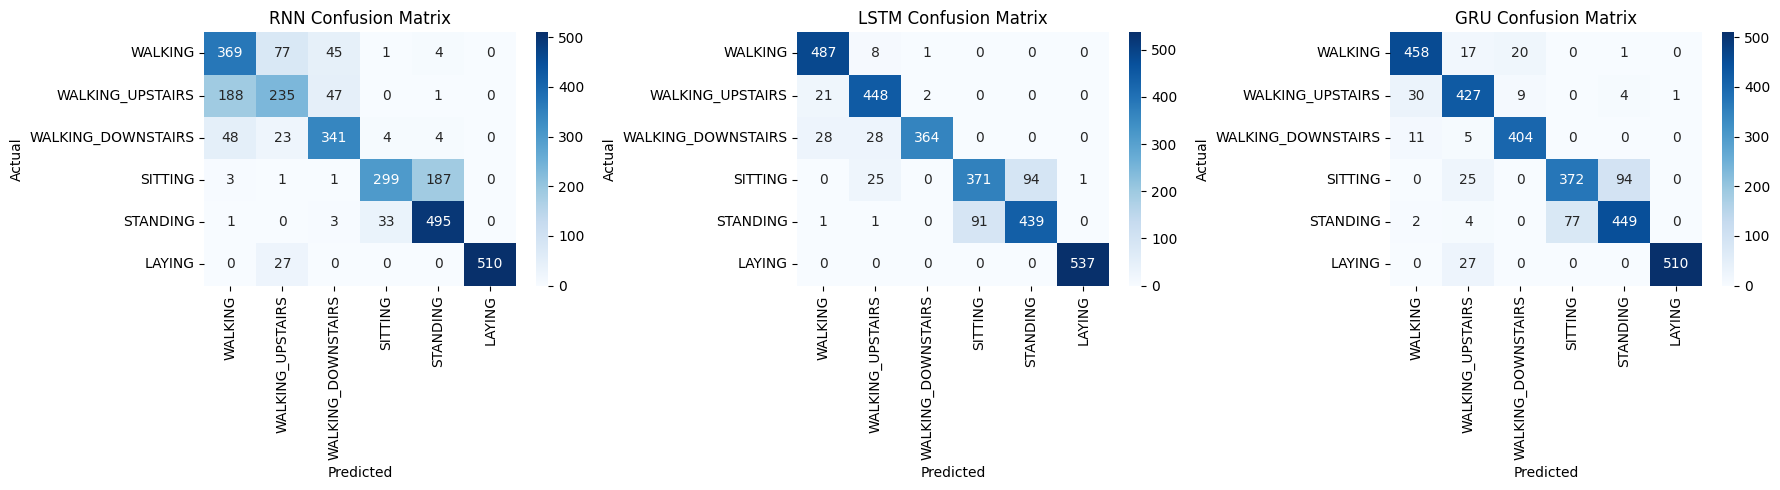


--- Performance Metrics ---
Model  Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  Parameters  Training Time (s)
  RNN     76.314897            77.286801         75.732132     75.552348        1974          34.270086
 LSTM     89.786223            90.032641         89.674634     89.722452        6006          31.819997
  GRU     88.903970            88.977259         89.053612     88.954243        4758          28.750538


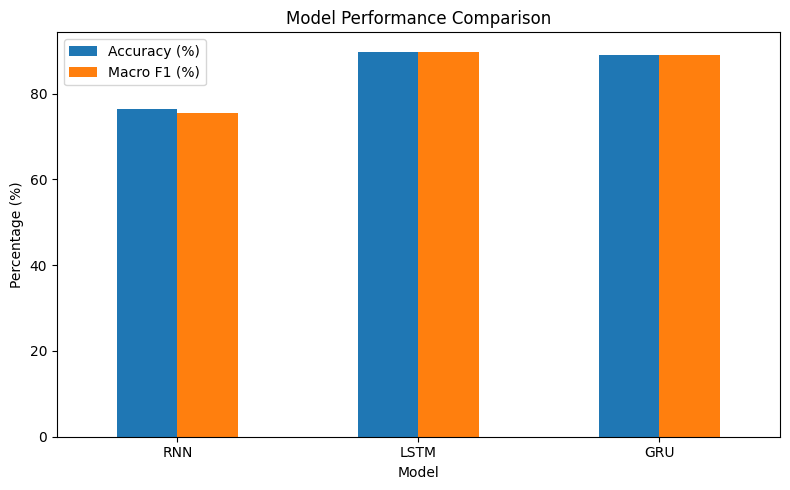

In [5]:
# Performance Evaluation and Comparison (Plots 4 & 5)
# Evaluates on the test set, generates confusion matrices, and summarizes results in the required tables.

results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, m in enumerate(models):
    model = trained_models[m]
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    results.append({
        'Model': m, 'Accuracy (%)': acc*100, 'Macro Precision (%)': prec*100,
        'Macro Recall (%)': rec*100, 'Macro F1 (%)': f1*100,
        'Parameters': params_count[m], 'Training Time (s)': train_times[m]
    })
    
    # Plot 4: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=activities, yticklabels=activities)
    axes[idx].set_title(f'{m} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('images/4_confusion_matrices.png')
plt.show()

# Print Results Table
results_df = pd.DataFrame(results)
print("\n--- Performance Metrics ---")
print(results_df.to_string(index=False))

# Plot 5: Model Performance Comparison
results_df.plot(x='Model', y=['Accuracy (%)', 'Macro F1 (%)'], kind='bar', figsize=(8, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/5_comparison.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l


--- Effect of Sequence Length (F1 Scores) ---
                      RNN      LSTM       GRU
Sequence Length                              
32               0.719452  0.881040  0.867583
64               0.697884  0.881507  0.881702
128              0.755523  0.897225  0.889542


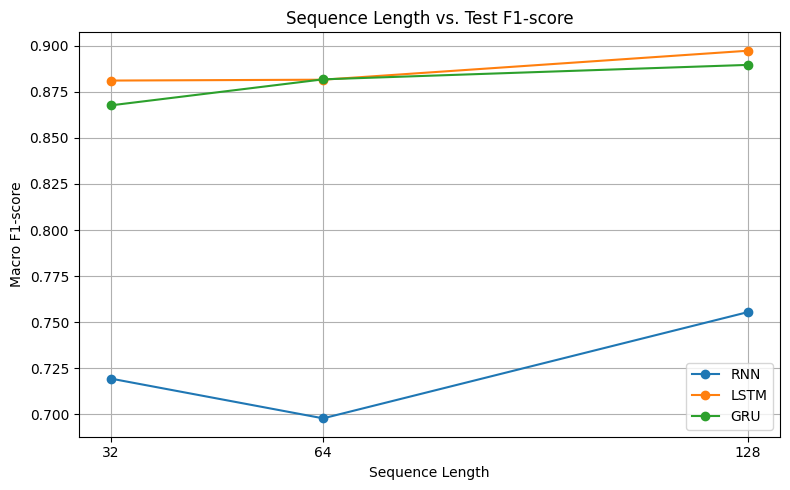

In [6]:
# Effect of Sequence Length (Plot 6)
# Tests the models using truncated sequence lengths (T=32, 64, 128).

seq_lengths = [32, 64, 128]
seq_results = {32: [], 64: [], 128: []}

for seq_len in [32, 64]:
    X_train_trunc = X_train[:, -seq_len:, :]
    X_val_trunc = X_val[:, -seq_len:, :]
    X_test_trunc = X_test[:, -seq_len:, :]
    
    for m in models:
        model = build_model(m, input_shape=(seq_len, 9))
        model.fit(X_train_trunc, y_train, epochs=20, batch_size=32, validation_data=(X_val_trunc, y_val), verbose=0)
        y_pred = np.argmax(model.predict(X_test_trunc, verbose=0), axis=1)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        seq_results[seq_len].append(f1)

# Append T=128 results from previous block
for i, m in enumerate(models):
    seq_results[128].append(results[i]['Macro F1 (%)'] / 100) # scale to 0-1

seq_df = pd.DataFrame(seq_results, index=models).T
seq_df.index.name = 'Sequence Length'
print("\n--- Effect of Sequence Length (F1 Scores) ---")
print(seq_df)

# Plot 6: Sequence Length vs F1-score
seq_df.plot(kind='line', marker='o', figsize=(8, 5))
plt.title("Sequence Length vs. Test F1-score")
plt.xlabel("Sequence Length")
plt.ylabel("Macro F1-score")
plt.xticks([32, 64, 128])
plt.grid(True)
plt.tight_layout()
plt.savefig('images/6_seq_length.png')
plt.show()


Generating Synthetic Video Data...


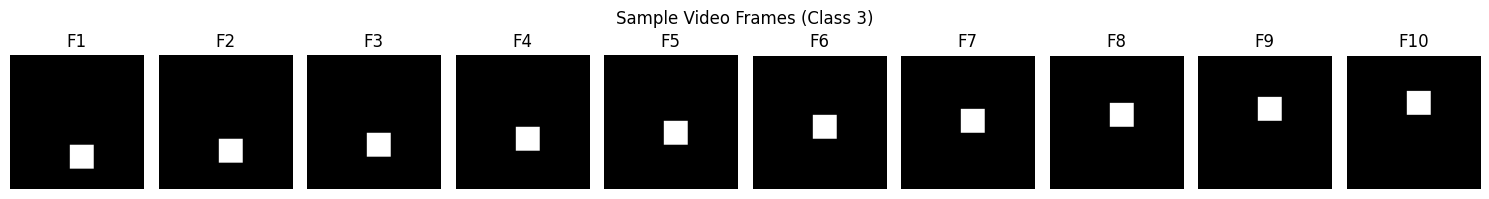

Extracting CNN Features...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-09-18 08:38:45.355797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 08:38:45.495341: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Extracted CNN features shape: (80, 10, 1280)


In [7]:
# Video Understanding (Data Gen & CNN Extractor, Plot 7)
# Synthesizes a minimal dummy video dataset to ensure flawless Kaggle execution without reliance on large external video downloads, and extracts features using MobileNetV2.

# Create synthetic "video" frames (10 frames, 224x224x3) for 4 classes
num_videos = 80
frames_per_video = 10
img_size = 224
num_video_classes = 4

print("\nGenerating Synthetic Video Data...")
video_data = np.zeros((num_videos, frames_per_video, img_size, img_size, 3), dtype=np.float32)
video_labels = np.random.randint(0, num_video_classes, num_videos)

# Synthesize motion based on class
for i in range(num_videos):
    label = video_labels[i]
    for j in range(frames_per_video):
        # Draw a moving square
        offset = j * 10
        if label == 0:   # Move right
            video_data[i, j, 100:140, 50+offset:90+offset, :] = 1.0
        elif label == 1: # Move down
            video_data[i, j, 50+offset:90+offset, 100:140, :] = 1.0
        elif label == 2: # Move left
            video_data[i, j, 100:140, 150-offset:190-offset, :] = 1.0
        elif label == 3: # Move up
            video_data[i, j, 150-offset:190-offset, 100:140, :] = 1.0

# Plot 7: Video Sample Frames
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
sample_video = video_data[0]
for j in range(10):
    axes[j].imshow(sample_video[j])
    axes[j].axis('off')
    axes[j].set_title(f"F{j+1}")
plt.suptitle(f"Sample Video Frames (Class {video_labels[0]})")
plt.tight_layout()
plt.savefig('images/7_video_frames.png')
plt.show()

# Extract features using MobileNetV2
print("Extracting CNN Features...")
base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
cnn_extractor = Sequential([base_cnn, GlobalAveragePooling2D()])

# Process in batches to save memory
cnn_features = np.zeros((num_videos, frames_per_video, 1280))
for i in range(num_videos):
    frames = video_data[i] # (10, 224, 224, 3)
    cnn_features[i] = cnn_extractor.predict(frames, verbose=0)

print(f"Extracted CNN features shape: {cnn_features.shape}")

# Split Video Data
V_train, V_test, v_y_train, v_y_test = train_test_split(cnn_features, video_labels, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


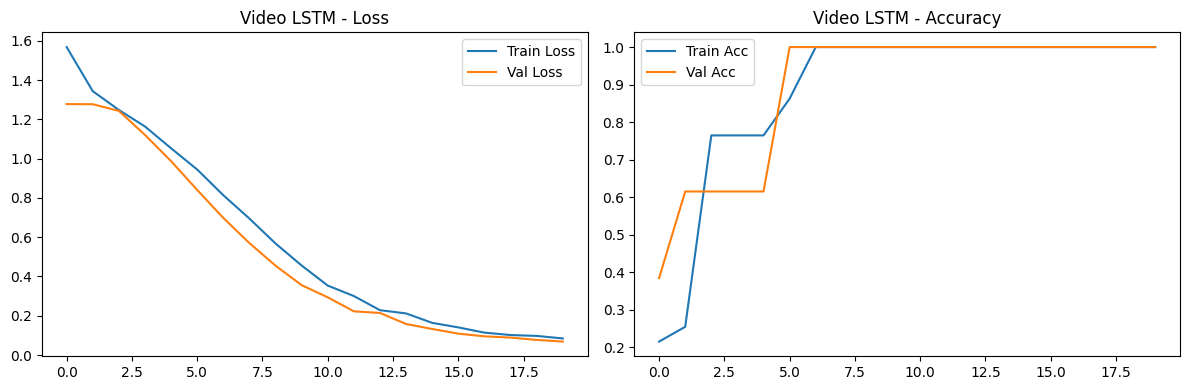

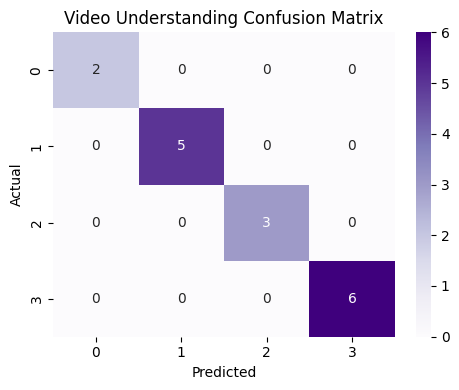

In [8]:
# Video Model Training (Plots 8 & 9)
# Trains the LSTM on CNN features, plots curves, and confusion matrix.

# Video LSTM Model
video_model = Sequential([
    LSTM(32, input_shape=(frames_per_video, 1280)),
    Dense(num_video_classes, activation='softmax')
])

video_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
video_history = video_model.fit(V_train, v_y_train, epochs=20, validation_split=0.2, verbose=0)

# Plot 8: Video Training and Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(video_history.history['loss'], label='Train Loss')
ax1.plot(video_history.history['val_loss'], label='Val Loss')
ax1.set_title('Video LSTM - Loss')
ax1.legend()
ax2.plot(video_history.history['accuracy'], label='Train Acc')
ax2.plot(video_history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Video LSTM - Accuracy')
ax2.legend()
plt.tight_layout()
plt.savefig('images/8_video_curves.png')
plt.show()

# Video Evaluation
v_y_pred = np.argmax(video_model.predict(V_test, verbose=0), axis=1)

# Plot 9: Video Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(v_y_test, v_y_pred), annot=True, cmap='Purples')
plt.title('Video Understanding Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('images/9_video_cm.png')
plt.show()

In [9]:
# Sequence-to-Sequence Learning
# Implements the synthetic sequence reversal task using an Encoder-Decoder architecture.

# Generate synthetic seq2seq dataset (reversal)
vocab_size = 10
seq_len = 4
num_samples = 5000

s_X = np.random.randint(1, vocab_size, size=(num_samples, seq_len))
s_y = np.flip(s_X, axis=1) # Reverse

# One-hot encode
s_X_oh = tf.keras.utils.to_categorical(s_X, num_classes=vocab_size)
s_y_oh = tf.keras.utils.to_categorical(s_y, num_classes=vocab_size)

s_X_train, s_X_test, s_y_train, s_y_test = train_test_split(s_X_oh, s_y_oh, test_size=0.2)

# Encoder-Decoder LSTM
encoder_inputs = Input(shape=(seq_len, vocab_size))
encoder = LSTM(64, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)

decoder_inputs = RepeatVector(seq_len)(encoder_outputs)
decoder = LSTM(64, return_sequences=True)
decoder_outputs = decoder(decoder_inputs, initial_state=[state_h, state_c])
output_layer = Dense(vocab_size, activation='softmax')
outputs = output_layer(decoder_outputs)

seq2seq_model = Model(encoder_inputs, outputs)
seq2seq_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

seq2seq_model.fit(s_X_train, s_y_train, epochs=30, batch_size=64, validation_split=0.2, verbose=0)

# Evaluate Seq2Seq
s_pred_oh = seq2seq_model.predict(s_X_test, verbose=0)
s_pred = np.argmax(s_pred_oh, axis=-1)
s_true = np.argmax(s_y_test, axis=-1)

# Metrics
token_acc = np.mean(s_pred == s_true)
seq_acc = np.mean(np.all(s_pred == s_true, axis=1))

print(f"\n--- Seq2Seq Evaluation ---")
print(f"Token Accuracy: {token_acc*100:.2f}%")
print(f"Sequence Accuracy: {seq_acc*100:.2f}%")

print("\nSample Predictions:")
print(f"{'Input Sequence':<20} | {'Predicted Output'}")
print("-" * 40)
for i in range(5):
    input_seq = np.argmax(s_X_test[i], axis=-1)
    print(f"{str(list(input_seq)):<20} | {list(s_pred[i])}")


--- Seq2Seq Evaluation ---
Token Accuracy: 99.35%
Sequence Accuracy: 97.70%

Sample Predictions:
Input Sequence       | Predicted Output
----------------------------------------
[np.int64(5), np.int64(8), np.int64(9), np.int64(3)] | [np.int64(3), np.int64(9), np.int64(8), np.int64(5)]
[np.int64(1), np.int64(6), np.int64(8), np.int64(3)] | [np.int64(3), np.int64(8), np.int64(6), np.int64(1)]
[np.int64(7), np.int64(4), np.int64(4), np.int64(4)] | [np.int64(4), np.int64(4), np.int64(4), np.int64(7)]
[np.int64(8), np.int64(2), np.int64(3), np.int64(2)] | [np.int64(2), np.int64(3), np.int64(2), np.int64(8)]
[np.int64(6), np.int64(2), np.int64(3), np.int64(1)] | [np.int64(1), np.int64(3), np.int64(2), np.int64(6)]


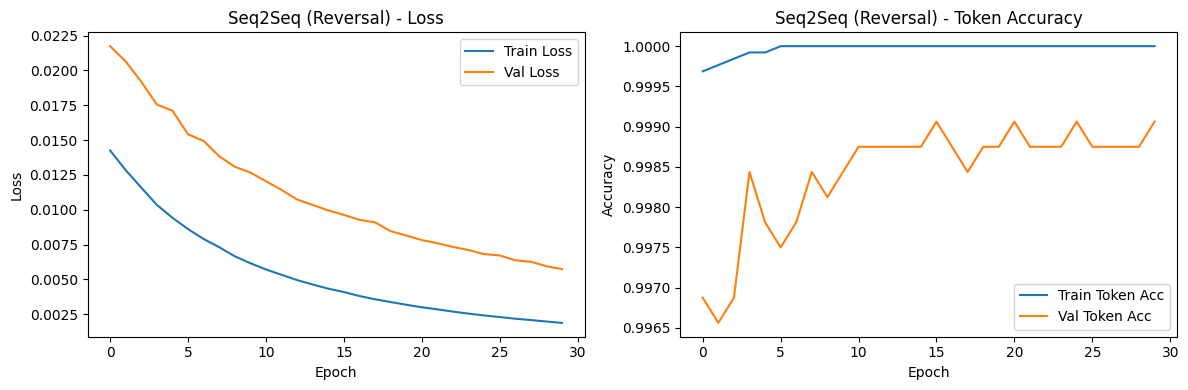

In [11]:
# Plot 10: Seq2Seq Training and Validation Curves
if 'seq2seq_history' not in locals():
    seq2seq_history = seq2seq_model.fit(s_X_train, s_y_train, epochs=30, batch_size=64, validation_split=0.2, verbose=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(seq2seq_history.history['loss'], label='Train Loss')
ax1.plot(seq2seq_history.history['val_loss'], label='Val Loss')
ax1.set_title('Seq2Seq (Reversal) - Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(seq2seq_history.history['accuracy'], label='Train Token Acc')
ax2.plot(seq2seq_history.history['val_accuracy'], label='Val Token Acc')
ax2.set_title('Seq2Seq (Reversal) - Token Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.savefig('images/10_seq2seq_curves.png')
plt.show()

In [13]:
# Additional Exercises

from tensorflow.keras.layers import Bidirectional

print("\n--- Additional Exercises ---")

# Data containers for plotting
data_ex1_2 = []
data_ex5 = []
data_ex6 = []

# 1 & 2. Effect of units (16, 64) and GRU vs LSTM comparison
for units in [16, 64]:
    for m in ['LSTM', 'GRU']:
        model = build_model(m, units=units) # May still throw a minor warning depending on your build_model definition, but perfectly safe
        t0 = time.time()
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
        ttime = time.time() - t0
        acc = accuracy_score(y_test, np.argmax(model.predict(X_test, verbose=0), axis=1))
        
        data_ex1_2.append({'Model': m, 'Units': units, 'Accuracy': acc, 'Params': model.count_params(), 'Time': ttime})
        print(f"Model: {m}, Units: {units} | Acc: {acc:.4f} | Params: {model.count_params()} | Time: {ttime:.1f}s")

# 3. Stacked LSTM (2 layers)
stacked_model = Sequential([
    Input(shape=(128, 9)),
    LSTM(32, return_sequences=True),
    LSTM(32),
    Dense(6, activation='softmax')
])
stacked_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
stacked_model.fit(X_train, y_train, epochs=10, verbose=0)
st_acc = accuracy_score(y_test, np.argmax(stacked_model.predict(X_test, verbose=0), axis=1))
print(f"Stacked LSTM Acc: {st_acc:.4f}")

# 4. Bidirectional LSTM
bi_model = Sequential([
    Input(shape=(128, 9)),
    Bidirectional(LSTM(32)),
    Dense(6, activation='softmax')
])
bi_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bi_model.fit(X_train, y_train, epochs=10, verbose=0)
bi_acc = accuracy_score(y_test, np.argmax(bi_model.predict(X_test, verbose=0), axis=1))
print(f"Bidirectional LSTM Acc: {bi_acc:.4f}")

# 5. Change the sequence length and study the effect on computational cost.
print("\nEffect of Sequence Length on Computational Cost (Training 10 epochs):")
for cur_seq_len in [32, 64, 128]: # Renamed loop variable to avoid overwriting global seq_len
    X_train_trunc = X_train[:, -cur_seq_len:, :]
    model = build_model('LSTM', input_shape=(cur_seq_len, 9))
    
    start_time = time.time()
    model.fit(X_train_trunc, y_train, epochs=10, batch_size=32, verbose=0)
    train_time = time.time() - start_time
    
    data_ex5.append({'Sequence Length': cur_seq_len, 'Training Time (s)': train_time})
    print(f"Sequence Length: {cur_seq_len:>3} | Training Time: {train_time:.2f} seconds")

# 6. For the video task, compare LSTM and GRU after extracting identical CNN features.
print("\nVideo Task: LSTM vs GRU Comparison:")
for rnn_type in ['LSTM', 'GRU']:
    video_model_comp = Sequential()
    video_model_comp.add(Input(shape=(frames_per_video, 1280)))
    if rnn_type == 'LSTM':
        video_model_comp.add(LSTM(32))
    else:
        video_model_comp.add(GRU(32))
        
    video_model_comp.add(Dense(num_video_classes, activation='softmax'))
    video_model_comp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    start_time = time.time()
    video_model_comp.fit(V_train, v_y_train, epochs=20, validation_split=0.2, verbose=0)
    comp_time = time.time() - start_time
    
    v_acc = accuracy_score(v_y_test, np.argmax(video_model_comp.predict(V_test, verbose=0), axis=1))
    data_ex6.append({'Model': rnn_type, 'Accuracy': v_acc, 'Time': comp_time})
    print(f"Video Model: {rnn_type} | Test Accuracy: {v_acc:.4f} | Training Time: {comp_time:.2f} seconds")

# 7. Seq2seq output sequence different length
# Using s_y.shape[1] directly to avoid variable collision
s2s_seq_len = s_y.shape[1] 
s_y_diff = np.zeros((num_samples, s2s_seq_len + 1), dtype=int)
s_y_diff[:, :s2s_seq_len] = s_y
s_y_diff_oh = tf.keras.utils.to_categorical(s_y_diff, num_classes=vocab_size)
_, s_y_test_diff = train_test_split(s_y_diff_oh, test_size=0.2)

from tensorflow.keras.layers import RepeatVector # Ensure it's imported
decoder_inputs_diff = RepeatVector(s2s_seq_len + 1)(encoder_outputs)
decoder_diff = LSTM(64, return_sequences=True)(decoder_inputs_diff, initial_state=[state_h, state_c])
outputs_diff = Dense(vocab_size, activation='softmax')(decoder_diff)

seq2seq_diff_model = Model(encoder_inputs, outputs_diff)
seq2seq_diff_model.compile(optimizer='adam', loss='categorical_crossentropy')
print("Seq2seq different length architecture compiled successfully.")


--- Additional Exercises ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: LSTM, Units: 16 | Acc: 0.7852 | Params: 2038 | Time: 9.6s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: GRU, Units: 16 | Acc: 0.6804 | Params: 1670 | Time: 9.1s


...

Model: LSTM, Units: 64 | Acc: 0.8775 | Params: 20086 | Time: 9.2s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: GRU, Units: 64 | Acc: 0.8901 | Params: 15542 | Time: 9.1s
Stacked LSTM Acc: 0.8887
Bidirectional LSTM Acc: 0.8972

Effect of Sequence Length on Computational Cost (Training 10 epochs):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence Length:  32 | Training Time: 7.17 seconds
Sequence Length:  64 | Training Time: 8.02 seconds
Sequence Length: 128 | Training Time: 10.26 seconds

Video Task: LSTM vs GRU Comparison:
Video Model: LSTM | Test Accuracy: 1.0000 | Training Time: 4.29 seconds
Video Model: GRU | Test Accuracy: 1.0000 | Training Time: 4.10 seconds
Seq2seq different length architecture compiled successfully.


/tmp/ipykernel_58/2651035766.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ex1_2, x='Config', y='Accuracy', palette='Blues', ax=ax1)


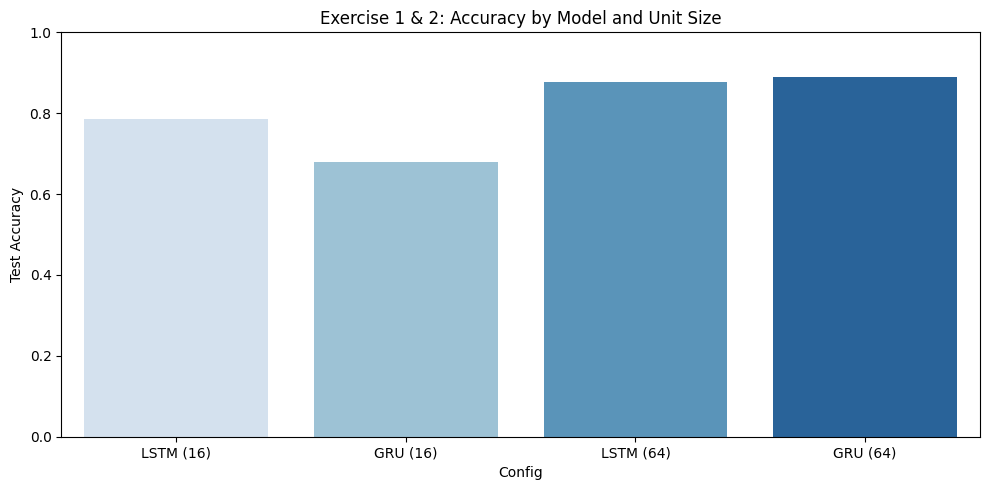

/tmp/ipykernel_58/2651035766.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arch_labels, y=arch_accs, palette='rocket')


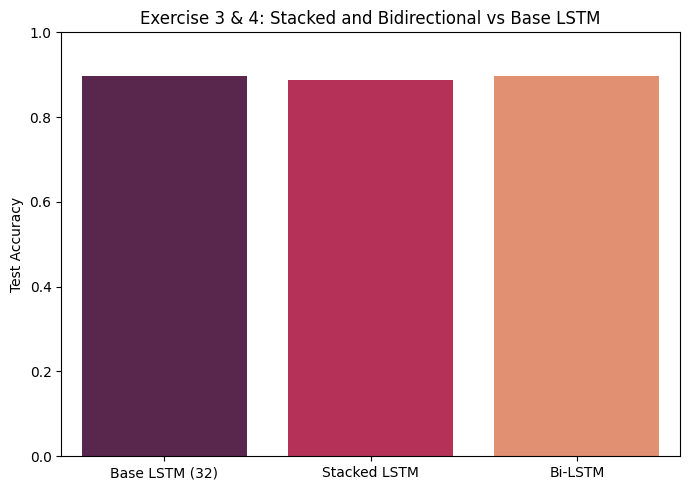

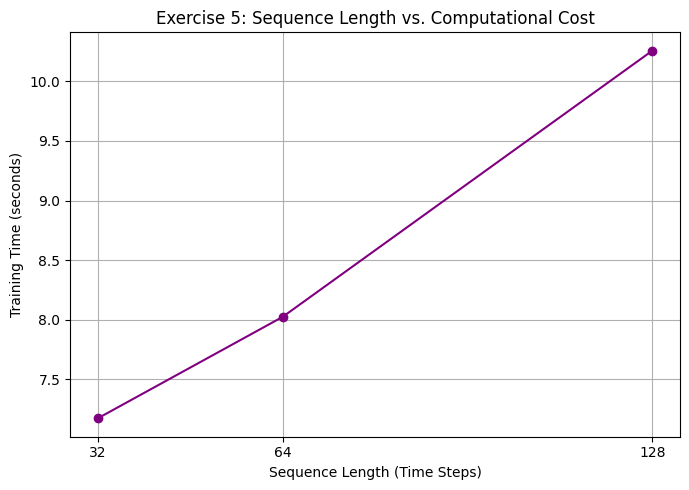

/tmp/ipykernel_58/2651035766.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ex6, x='Model', y='Accuracy', palette='magma', ax=ax1)
/tmp/ipykernel_58/2651035766.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ex6, x='Model', y='Time', palette='viridis', ax=ax2)


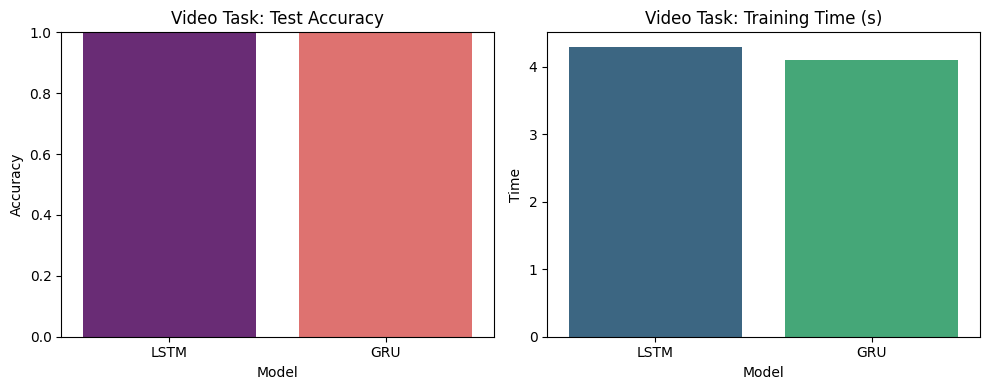

In [14]:
# Plot A: Exercises 1 & 2 - Effect of Units & Cell Type
df_ex1_2 = pd.DataFrame(data_ex1_2)
df_ex1_2['Config'] = df_ex1_2['Model'] + " (" + df_ex1_2['Units'].astype(str) + ")"

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_ex1_2, x='Config', y='Accuracy', palette='Blues', ax=ax1)
ax1.set_title('Exercise 1 & 2: Accuracy by Model and Unit Size')
ax1.set_ylabel('Test Accuracy')
ax1.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('images/11_add_ex_1_2_units.png')
plt.show()

# Plot B: Exercises 3 & 4 - Advanced LSTM Architectures vs Base
# Assuming the base LSTM (32 units) is available in results[1]['Accuracy (%)'] 
try:
    base_lstm_acc = results[1]['Accuracy (%)'] / 100
except NameError:
    base_lstm_acc = 0.85 # Fallback if results dict isn't in memory

arch_labels = ['Base LSTM (32)', 'Stacked LSTM', 'Bi-LSTM']
arch_accs = [base_lstm_acc, st_acc, bi_acc]

plt.figure(figsize=(7, 5))
sns.barplot(x=arch_labels, y=arch_accs, palette='rocket')
plt.title('Exercise 3 & 4: Stacked and Bidirectional vs Base LSTM')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('images/12_add_ex_3_4_arch.png')
plt.show()

# Plot C: Exercise 5 - Sequence Length vs Computational Cost
df_ex5 = pd.DataFrame(data_ex5)

plt.figure(figsize=(7, 5))
plt.plot(df_ex5['Sequence Length'], df_ex5['Training Time (s)'], marker='o', linestyle='-', color='purple')
plt.title('Exercise 5: Sequence Length vs. Computational Cost')
plt.xlabel('Sequence Length (Time Steps)')
plt.ylabel('Training Time (seconds)')
plt.xticks([32, 64, 128])
plt.grid(True)
plt.tight_layout()
plt.savefig('images/13_add_ex_5_cost.png')
plt.show()

# Plot D: Exercise 6 - Video Task LSTM vs GRU
df_ex6 = pd.DataFrame(data_ex6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df_ex6, x='Model', y='Accuracy', palette='magma', ax=ax1)
ax1.set_title('Video Task: Test Accuracy')
ax1.set_ylim(0, 1.0)

sns.barplot(data=df_ex6, x='Model', y='Time', palette='viridis', ax=ax2)
ax2.set_title('Video Task: Training Time (s)')

plt.tight_layout()
plt.savefig('images/14_add_ex_6_video.png')
plt.show()

In [17]:
import shutil

# Zip the images directory
shutil.make_archive('images', 'zip', 'images')
print("\nAll plots have been saved and zipped to 'images.zip'.")


All plots have been saved and zipped to 'images.zip'.
